<a href="https://colab.research.google.com/github/Franklin-Custodio/challenge-tiendas/blob/main/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


# **Uniendo los datos de las tiendas**

In [3]:
tienda["Tienda"] = "Tienda 1"
tienda2["Tienda"] = "Tienda 2"
tienda3["Tienda"] = "Tienda 3"
tienda4["Tienda"] = "Tienda 4"

todas_tiendas = pd.concat([tienda, tienda2, tienda3, tienda4])

#1. Análisis de facturación



In [4]:
facturacion = todas_tiendas.groupby("Tienda")["Precio"].sum().sort_values(ascending=False)
facturacion

,Precio
Tienda,
Tienda 1,1.150880e+09
Tienda 2,1.116344e+09
Tienda 3,1.098020e+09
Tienda 4,1.038376e+09


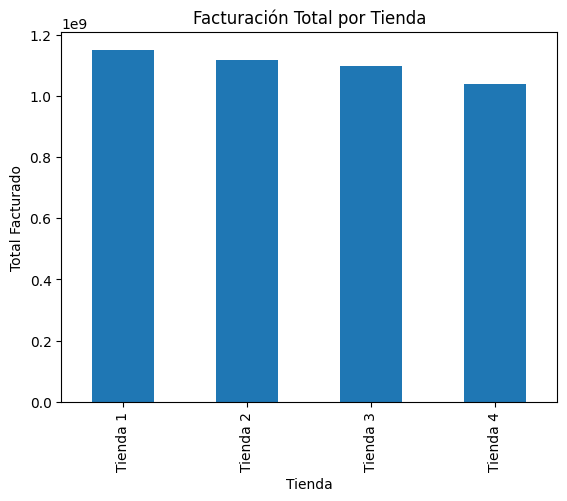

In [5]:
import matplotlib.pyplot as plt

facturacion.plot(kind="bar")
plt.title("Facturación Total por Tienda")
plt.ylabel("Total Facturado")
plt.show()

# 2. Ventas por categoría

In [7]:
categoria1 = tienda["Categoría del Producto"].value_counts()
categoria2 = tienda2["Categoría del Producto"].value_counts()
categoria3 = tienda3["Categoría del Producto"].value_counts()
categoria4 = tienda4["Categoría del Producto"].value_counts()

print(categoria1)
print(categoria2)
print(categoria3)
print(categoria4)

Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171
Name: count, dtype: int64
Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181
Name: count, dtype: int64
Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                     185
Instrumentos musicales     177
Artículos para el hogar    177
Name: count, dtype: int64
Categoría del Producto
Muebles                    480
Electrónicos               451
Juguetes                

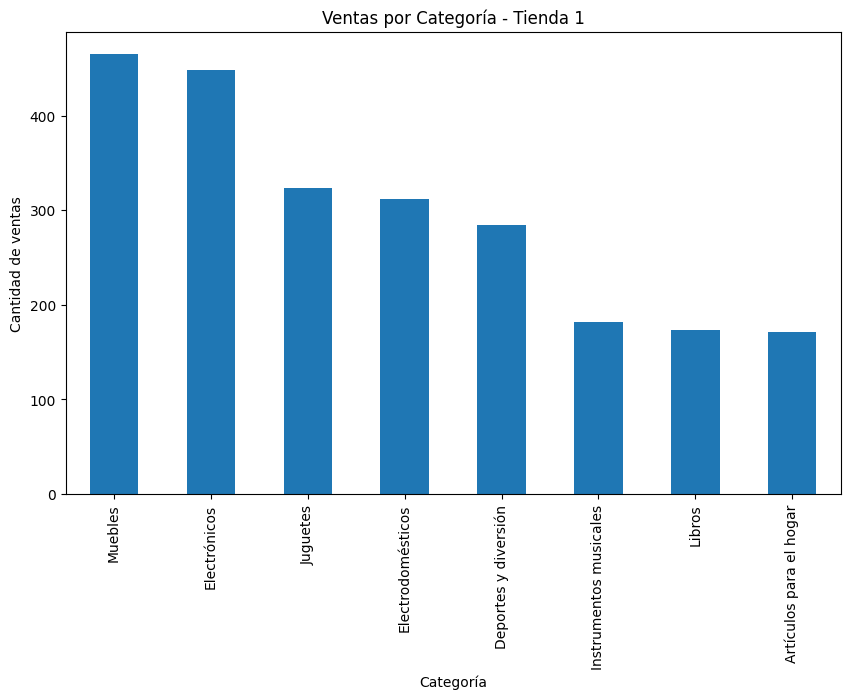

In [8]:
categoria1.plot(kind="bar", figsize=(10,6))
plt.title("Ventas por Categoría - Tienda 1")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de ventas")
plt.show()

# 3. Calificación promedio de la tienda


In [9]:
calif1 = tienda["Calificación"].mean()
calif2 = tienda2["Calificación"].mean()
calif3 = tienda3["Calificación"].mean()
calif4 = tienda4["Calificación"].mean()

print("Tienda 1:", calif1)
print("Tienda 2:", calif2)
print("Tienda 3:", calif3)
print("Tienda 4:", calif4)

Tienda 1: 3.976685036032217
Tienda 2: 4.037303942348453
Tienda 3: 4.048325561678677
Tienda 4: 3.9957591178965224


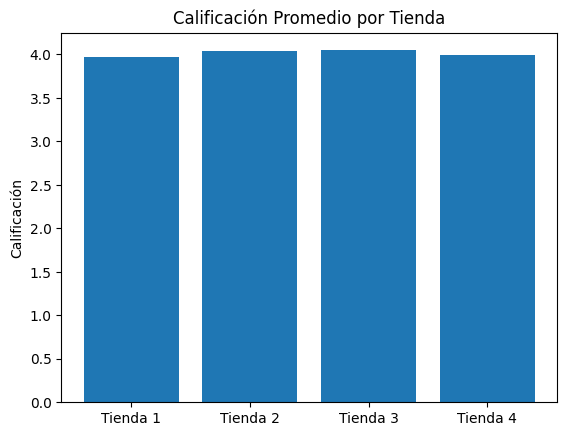

In [11]:
calificaciones = [calif1, calif2, calif3, calif4]
tiendas = facturacion.index.tolist()

plt.bar(tiendas, calificaciones)
plt.title("Calificación Promedio por Tienda")
plt.ylabel("Calificación")
plt.show()

# 4. Productos más y menos vendidos

In [12]:
mas_vendidos = tienda["Producto"].value_counts().head(10)
menos_vendidos = tienda["Producto"].value_counts().tail(10)

print("Más vendidos")
print(mas_vendidos)

print("Menos vendidos")
print(menos_vendidos)

Más vendidos
Producto
Microondas                 60
TV LED UHD 4K              60
Armario                    60
Secadora de ropa           58
Mesa de noche              56
Bloques de construcción    56
Balón de baloncesto        55
Bicicleta                  54
Vaso térmico               54
Refrigerador               54
Name: count, dtype: int64
Menos vendidos
Producto
Muñeca bebé                    40
Mesa de comedor                40
Dinosaurio Rex                 40
Cuerda para saltar             40
Mochila                        39
Ciencia de datos con Python    39
Pandereta                      36
Olla de presión                35
Auriculares con micrófono      33
Celular ABXY                   33
Name: count, dtype: int64


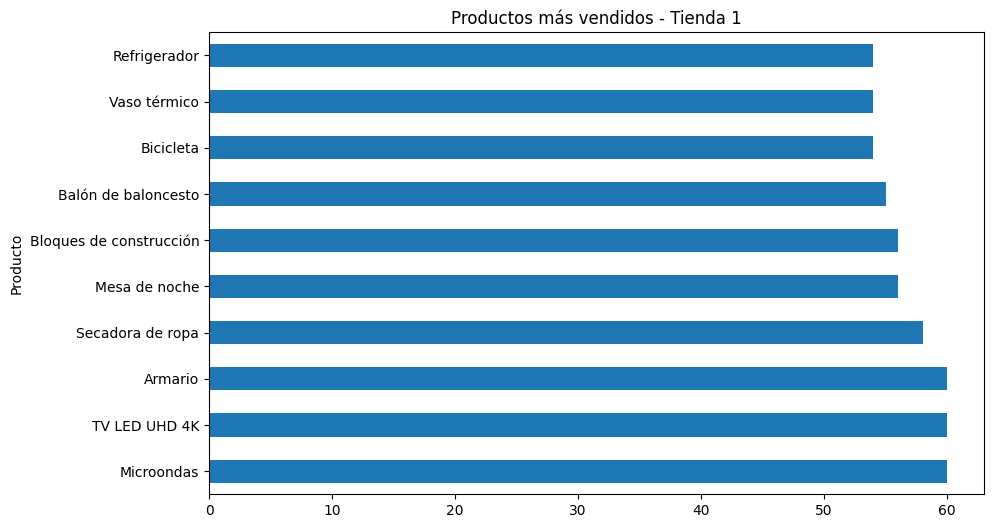

In [13]:
mas_vendidos.plot(kind="barh", figsize=(10,6))
plt.title("Productos más vendidos - Tienda 1")
plt.show()

# 5. Envío promedio por tienda

In [14]:
envio1 = tienda["Costo de envío"].mean()
envio2 = tienda2["Costo de envío"].mean()
envio3 = tienda3["Costo de envío"].mean()
envio4 = tienda4["Costo de envío"].mean()

print(envio1, envio2, envio3, envio4)

26018.60958033065 25216.235693090293 24805.680373039424 23459.457167090754


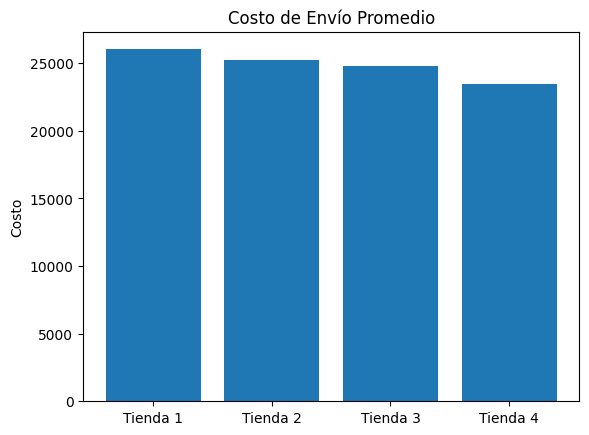

In [15]:
envios = [envio1, envio2, envio3, envio4]

plt.bar(tiendas, envios)
plt.title("Costo de Envío Promedio")
plt.ylabel("Costo")
plt.show()

# **Recomendación final:**
Luego de analizar los datos de facturación, las categorías más vendidas, las calificaciones de los clientes, los productos más vendidos y el costo promedio de envío, se observa que la Tienda 4 presenta el menor rendimiento general en comparación con las demás tiendas; por lo tanto se recomienda al señor Juan vender la **tienda 4**.